## BERTScore

In [ ]:
!pip install bert-score -q
!pip install pandas openpyxl -q
print(" Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.4 MB/s eta 0:00:00
 Done!


In [ ]:
import pandas as pd
import torch
from bert_score import score

print(f"Device: {'GPU ' if torch.cuda.is_available() else 'CPU (slower)'}")

Device: GPU 


In [ ]:

df = pd.read_excel(
    "/content/complete_dataset.csv.xlsx"
)

# Only valid rows
df_valid = df[
    df['post_edited_ad'].notna() &
    (df['post_edited_ad'] != '') &
    (df['post_edited_ad'] != 'nan')
].copy()

print(f" Total: {len(df)}")
print(f" Valid for BERTScore: {len(df_valid)}")
print(f"Columns: {list(df.columns)}")

📊 Total: 467
✅ Valid for BERTScore: 467
Columns: ['video_id', 'title', 'channel_name', 'published_at', 'duration_secs', 'view_count', 'like_count', 'shorts_url', 'category', 'is_instructional', 'is_good_cooking', 'gemini_zero_shot', 'gemini_five_shot', 'qwen_zero_shot', 'qwen_five_shot', 'post_edited_ad']


In [ ]:
#  Post-Edited as Reference
print(" OPTION 1 — Post-Edited as Reference")
print("(Standard BERTScore evaluation)")
print("="*55)

# Reference =  post-edited descriptions
refs = df_valid['post_edited_ad'].tolist()

option1_results = {}

models_to_eval = [
    ("Gemini Zero Shot", "gemini_zero_shot"),
    ("Gemini Five Shot", "gemini_five_shot"),
    ("Qwen Zero Shot",   "qwen_zero_shot"),
    ("Qwen Five Shot",   "qwen_five_shot"),
]

for name, col in models_to_eval:
    print(f"\nCalculating {name}...")
    candidates = df_valid[col].fillna('').tolist()

    P, R, F = score(
        candidates,
        refs,
        lang="en",
        verbose=False
    )

    avg_p = sum(P)/len(P)
    avg_r = sum(R)/len(R)
    avg_f = sum(F)/len(F)

    option1_results[name] = {
        'P': avg_p,
        'R': avg_r,
        'F1': avg_f
    }

    df_valid[f'bert1_{col}'] = [
        f.item() for f in F
    ]

    print(f" P:{avg_p:.4f} "
          f"R:{avg_r:.4f} "
          f"F1:{avg_f:.4f}")

 OPTION 1 — Post-Edited as Reference
(Standard BERTScore evaluation)

Calculating Gemini Zero Shot...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 P:0.8681 R:0.8828 F1:0.8750

Calculating Qwen Five Shot...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 P:0.8795 R:0.8832 F1:0.8813


In [ ]:
# Cross Model Comparison
print("\n OPTION 2 — Gemini Five Shot as Reference")
print("(Cross model comparison)")
print("="*55)

refs_gemini = df_valid[
    'gemini_five_shot'
].fillna('').tolist()

option2_results = {}

for name, col in [
    ("Gemini Zero Shot", "gemini_zero_shot"),
    ("Qwen Zero Shot",   "qwen_zero_shot"),
    ("Qwen Five Shot",   "qwen_five_shot"),
]:
    print(f"\nCalculating {name}...")
    candidates = df_valid[col].fillna('').tolist()

    P, R, F = score(
        candidates,
        refs_gemini,
        lang="en",
        verbose=False
    )

    avg_p = sum(P)/len(P)
    avg_r = sum(R)/len(R)
    avg_f = sum(F)/len(F)

    option2_results[name] = {
        'P': avg_p,
        'R': avg_r,
        'F1': avg_f
    }

    df_valid[f'bert2_{col}'] = [
        f.item() for f in F
    ]

    print(f"✅ P:{avg_p:.4f} "
          f"R:{avg_r:.4f} "
          f"F1:{avg_f:.4f}")


 OPTION 2 — Gemini Five Shot as Reference
(Cross model comparison)

Calculating Gemini Zero Shot...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ P:0.8640 R:0.9059 F1:0.8839

Calculating Qwen Zero Shot...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ P:0.8777 R:0.8804 F1:0.8786

Calculating Qwen Five Shot...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ P:0.8871 R:0.8794 F1:0.8831


In [ ]:
#  Zero vs Five Shot
print("\n OPTION 3 — Zero vs Five Shot")
print("(Effect of prompting strategy)")
print("="*55)

option3_results = {}

# Gemini Zero vs Gemini Five
print("\nGemini Zero vs Five Shot...")
P, R, F = score(
    df_valid['gemini_zero_shot'].fillna('').tolist(),
    df_valid['gemini_five_shot'].fillna('').tolist(),
    lang="en", verbose=False
)
avg_p = sum(P)/len(P)
avg_r = sum(R)/len(R)
avg_f = sum(F)/len(F)
option3_results['Gemini Zero vs Five'] = {
    'P': avg_p, 'R': avg_r, 'F1': avg_f
}
df_valid['bert3_gemini'] = [f.item() for f in F]
print(f" P:{avg_p:.4f} R:{avg_r:.4f} F1:{avg_f:.4f}")

# Qwen Zero vs Qwen Five
print("\nQwen Zero vs Five Shot...")
P, R, F = score(
    df_valid['qwen_zero_shot'].fillna('').tolist(),
    df_valid['qwen_five_shot'].fillna('').tolist(),
    lang="en", verbose=False
)
avg_p = sum(P)/len(P)
avg_r = sum(R)/len(R)
avg_f = sum(F)/len(F)
option3_results['Qwen Zero vs Five'] = {
    'P': avg_p, 'R': avg_r, 'F1': avg_f
}
df_valid['bert3_qwen'] = [f.item() for f in F]
print(f" P:{avg_p:.4f} R:{avg_r:.4f} F1:{avg_f:.4f}")


 OPTION 3 — Zero vs Five Shot
(Effect of prompting strategy)

Gemini Zero vs Five Shot...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 P:0.8640 R:0.9059 F1:0.8839

Qwen Zero vs Five Shot...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 P:0.8946 R:0.9060 F1:0.8998


In [ ]:
#  Full Summary Table
print(" COMPLETE BERTSCORE RESULTS")
print("\n Post-Edited Reference:")
print(f"{'Model':<25} {'P':>8} {'R':>8} {'F1':>8}")
print("-"*55)
for name, vals in option1_results.items():
    print(f"{name:<25} "
          f"{vals['P']:>8.4f} "
          f"{vals['R']:>8.4f} "
          f"{vals['F1']:>8.4f}")

print("\n  Gemini Five Reference:")
print(f"{'Model':<25} {'P':>8} {'R':>8} {'F1':>8}")
print("-"*55)
print(f"{'Gemini Five Shot':<25} "
      f"{'1.0000':>8} "
      f"{'1.0000':>8} "
      f"{'1.0000':>8} ← reference")
for name, vals in option2_results.items():
    print(f"{name:<25} "
          f"{vals['P']:>8.4f} "
          f"{vals['R']:>8.4f} "
          f"{vals['F1']:>8.4f}")

print("\n Zero vs Five Shot:")
print(f"{'Comparison':<30} {'P':>8} {'R':>8} {'F1':>8}")
print("-"*60)
for name, vals in option3_results.items():
    print(f"{name:<30} "
          f"{vals['P']:>8.4f} "
          f"{vals['R']:>8.4f} "
          f"{vals['F1']:>8.4f}")

print("\n" + "="*60)
print("Note: Higher F1 = more similar to reference")
print("Note: Option 1 has reference bias towards")
print("      Gemini Five Shot (post-edited source)")

 COMPLETE BERTSCORE RESULTS

 Post-Edited Reference:
Model                            P        R       F1
-------------------------------------------------------
Gemini Zero Shot            0.8492   0.9044   0.8752
Gemini Five Shot            0.9549   0.9778   0.9661
Qwen Zero Shot              0.8681   0.8828   0.8750
Qwen Five Shot              0.8795   0.8832   0.8813

  Gemini Five Reference:
Model                            P        R       F1
-------------------------------------------------------
Gemini Five Shot            1.0000   1.0000   1.0000 ← reference
Gemini Zero Shot            0.8640   0.9059   0.8839
Qwen Zero Shot              0.8777   0.8804   0.8786
Qwen Five Shot              0.8871   0.8794   0.8831

 Zero vs Five Shot:
Comparison                            P        R       F1
------------------------------------------------------------
Gemini Zero vs Five              0.8640   0.9059   0.8839
Qwen Zero vs Five                0.8946   0.9060   0.8998

Note: High

In [ ]:
#Save Results

# Merge scores back to main df
score_cols = [c for c in df_valid.columns
              if c.startswith('bert')]

df_final = df.merge(
    df_valid[['video_id'] + score_cols],
    on='video_id',
    how='left'
)

# Save
df_final.to_excel(
    "/content/dataset_bertscore_final.xlsx",
    index=False
)
print(" Saved!")

from google.colab import files
files.download(
    "/content/dataset_bertscore_final.xlsx"
)
print(" Downloaded!")

✅ Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloaded!


##GPT-4o as a judge

In [ ]:
!pip install openai opencv-python pandas openpyxl -q
print(" Done!")

✅ Done!


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
from openai import OpenAI
import pandas as pd
import os
import cv2
import base64
import time
import zipfile

# Setup OpenAI client
OPENAI_KEY = userdata.get('YOUR_API_KEY_HERE')
client = OpenAI(api_key=OPENAI_KEY)

print(" Setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete!


In [ ]:
# Unzip Videos
zip_path = "/content/drive/MyDrive/youtube_ad/videos (2).zip"

print(" Unzipping videos...")
os.makedirs("/content/videos", exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/videos")

print(" Unzipped!")

# Find video directory
video_dir = None
for root, dirs, files in os.walk("/content/videos"):
    mp4s = [f for f in files if f.endswith('.mp4')]
    if len(mp4s) > 10:
        video_dir = root
        print(f" Videos at: {root}")
        print(f"   Total: {len(mp4s)} files")
        break

📦 Unzipping videos...
✅ Unzipped!
✅ Videos at: /content/videos/videos/videos
   Total: 454 files


In [ ]:

# Load Dataset
df = pd.read_excel(
    "/content/drive/MyDrive/youtube_ad/complete_dataset.csv.xlsx"
)

df = df.rename(
    columns={'Column1': 'post_edited_ad'}
)

print(f" Total videos: {len(df)}")
print(f" Columns: {list(df.columns)}")

# Add judge columns
for col in [
    'gpt_judge_gemini_zero',
    'gpt_judge_gemini_five',
    'gpt_judge_qwen_zero',
    'gpt_judge_qwen_five'
]:
    if col not in df.columns:
        df[col] = ''

if 'gpt_judge_status' not in df.columns:
    df['gpt_judge_status'] = 'Pending'

pending = (df['gpt_judge_status'] == 'Pending').sum()
print(f" Pending: {pending}")

📊 Total videos: 467
✅ Columns: ['video_id', 'title', 'channel_name', 'published_at', 'duration_secs', 'view_count', 'like_count', 'shorts_url', 'category', 'is_instructional', 'is_good_cooking', 'gemini_zero_shot', 'gemini_five_shot', 'qwen_zero_shot', 'qwen_five_shot', 'post_edited_ad']
⏳ Pending: 467


In [ ]:
# Helper Functions

def extract_frames(video_path, num_frames=6):
    """Extract key frames from video as base64"""
    frames = []
    try:
        cap = cv2.VideoCapture(video_path)
        total = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total == 0:
            cap.release()
            return frames

        indices = [
            int(total * i / num_frames)
            for i in range(num_frames)
        ]

        for idx in indices:
            cap.set(
                cv2.CAP_PROP_POS_FRAMES, idx
            )
            ret, frame = cap.read()
            if ret:
                _, buffer = cv2.imencode(
                    '.jpg', frame,
                    [cv2.IMWRITE_JPEG_QUALITY, 85]
                )
                b64 = base64.b64encode(
                    buffer
                ).decode('utf-8')
                frames.append(b64)

        cap.release()
    except Exception as e:
        print(f"   Frame error: {e}")

    return frames


def judge_with_gpt(frames, description,
                   title, channel):
    """Send frames + description to GPT-4o"""

    judge_prompt = f"""You are an expert evaluator
of audio descriptions for blind and visually
impaired users.

Video title: {title}
Channel: {channel}

You are provided with {len(frames)} key frames
from a cooking YouTube Short alongside an
audio description written for it.

Evaluate the description on these 5 criteria:

1. ACCURACY (1-5)
   Does it describe the correct food?
   Are ingredients correct?
   Is anything hallucinated or wrong?

2. COMPLETENESS (1-5)
   Does it cover main cooking steps?
   Are important details included?

3. ORDER (1-5)
   Are steps in correct chronological order?

4. TERMINOLOGY (1-5)
   Does it use correct culinary terms?
   Is language specific not generic?

5. NATURALNESS (1-5)
   Does it read naturally?
   Would it work well read aloud
   to a blind person?

Scoring: 5=Excellent 4=Good 3=Acceptable
2=Poor 1=Very Poor

DESCRIPTION TO EVALUATE:
{description}

Respond in EXACTLY this format:
ACCURACY: [score]/5
COMPLETENESS: [score]/5
ORDER: [score]/5
TERMINOLOGY: [score]/5
NATURALNESS: [score]/5
OVERALL: [average]/5
HALLUCINATIONS: [yes/no] - [brief description]
FEEDBACK: [one sentence summary]"""

    # Build message with frames
    content = []

    # Add frames as images
    for i, frame_b64 in enumerate(frames):
        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{frame_b64}",
                "detail": "low"
            }
        })

    # Add text prompt
    content.append({
        "type": "text",
        "text": judge_prompt
    })

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "user",
                    "content": content
                }
            ],
            max_tokens=300,
            temperature=0
        )
        return response.choices[0].message.content

    except Exception as e:
        print(f"   GPT error: {e}")
        return None

print(" Functions ready!")

✅ Functions ready!


In [ ]:
MAX_VIDEOS = 454
SAVE_EVERY = 5

processed = 0
errors = 0
start_time = time.time()

print(f" Starting GPT-4o Judge!")
print(f" Target: {MAX_VIDEOS} videos")
print("="*50)

for index, row in df.iterrows():

    if processed >= MAX_VIDEOS:
        print(f"\n Done {MAX_VIDEOS}!")
        break

    if row['gpt_judge_status'] == 'Done':
        continue

    video_id = str(row['video_id'])
    title = str(row['title'])
    channel = str(row['channel_name'])

    if processed > 0:
        elapsed = time.time() - start_time
        avg = elapsed / processed
        eta = (MAX_VIDEOS - processed) * avg / 60
        print(f"\n[{processed+1}/{MAX_VIDEOS}]"
              f" ETA:{eta:.0f}m | {title[:35]}")
    else:
        print(f"\n[1/{MAX_VIDEOS}] {title[:40]}")

    # Find video file
    video_path = f"{video_dir}/{video_id}.mp4"
    if not os.path.exists(video_path):
        print(f"   Video not found!")
        df.at[index, 'gpt_judge_status'] = 'Missing'
        errors += 1
        continue

    # Extract frames
    print("  Extracting frames...")
    frames = extract_frames(video_path)
    if len(frames) == 0:
        print(f"   No frames extracted!")
        df.at[index, 'gpt_judge_status'] = 'Error'
        errors += 1
        continue
    print(f"   {len(frames)} frames extracted!")

    # Judge each description
    descriptions = {
        'gpt_judge_gemini_zero': str(
            row.get('gemini_zero_shot', '')
        ),
        'gpt_judge_gemini_five': str(
            row.get('gemini_five_shot', '')
        ),
        'gpt_judge_qwen_zero': str(
            row.get('qwen_zero_shot', '')
        ),
        'gpt_judge_qwen_five': str(
            row.get('qwen_five_shot', '')
        ),
    }

    video_success = True
    for col, desc in descriptions.items():
        if not desc or desc == 'nan':
            continue

        model_name = col.replace(
            'gpt_judge_', ''
        ).replace('_', ' ')
        print(f"  Judging {model_name}...")

        result = judge_with_gpt(
            frames, desc, title, channel
        )

        if result:
            df.at[index, col] = result
            print(f"   Done!")
        else:
            video_success = False
            print(f"   Failed!")

        time.sleep(2)

    df.at[index, 'gpt_judge_status'] = \
        'Done' if video_success else 'Partial'
    processed += 1

    # Save progress
    if processed % SAVE_EVERY == 0:
        df.to_excel(
            "/content/gpt_judge_results.xlsx",
            index=False
        )
        elapsed_m = (time.time()-start_time)/60
        print(f"\n   Saved! "
              f"{processed} done | "
              f"{elapsed_m:.1f} mins")

    time.sleep(3)

# Final save
df.to_excel(
    "/content/gpt_judge_results.xlsx",
    index=False
)

total_time = (time.time()-start_time)/60
print(f"\n DONE!")
print(f"   Processed: {processed}")
print(f"   Errors:    {errors}")
print(f"   Time:      {total_time:.1f} mins")

from google.colab import files
files.download("/content/gpt_judge_results.xlsx")

 Starting GPT-4o Judge!
 Target: 454 videos

[1/454] Using PRAWN HEADS For Pasta Sauce?! #sho
   Video not found!

[1/454] Is cultured butter worth it? ??
   Video not found!

[1/454] I brought in a coffee specialist @FlairE
  Extracting frames...
   No frames extracted!

[1/454] The famous "Death by Chocolate" E?clair 
   Video not found!

[1/454] Remember the infamous pizza ball?!
  Extracting frames...
   6 frames extracted!
  Judging gemini zero...
   Done!
  Judging gemini five...
   Done!
  Judging qwen zero...
   Done!
  Judging qwen five...
   Done!

[2/454] ETA:142m | I cooked chicken in REAL lava!
  Extracting frames...
   6 frames extracted!
  Judging gemini zero...
   Done!
  Judging gemini five...
   Done!
  Judging qwen zero...
   Done!
  Judging qwen five...
   Done!

[3/454] ETA:145m | The perfect fall meal: coq au vin
  Extracting frames...
   6 frames extracted!
  Judging gemini zero...
   Done!
  Judging gemini five...
   Done!
  Judging qwen zero...
   Done!
  Judgi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import re
import pandas as pd

df = pd.read_excel(
    "/content/gpt_judge_results.xlsx"
)

def parse_score(text, metric):
    if not text or str(text) == 'nan':
        return None
    pattern = rf'{metric}:\s*(\d+(?:\.\d+)?)/5'
    match = re.search(
        pattern, str(text), re.IGNORECASE
    )
    return float(match.group(1)) if match else None

metrics = [
    'ACCURACY', 'COMPLETENESS', 'ORDER',
    'TERMINOLOGY', 'NATURALNESS', 'OVERALL'
]

models = [
    ('gpt_judge_gemini_zero', 'Gemini Zero'),
    ('gpt_judge_gemini_five', 'Gemini Five'),
    ('gpt_judge_qwen_zero',   'Qwen Zero'),
    ('gpt_judge_qwen_five',   'Qwen Five'),
]

print(" GPT-4o JUDGE RESULTS")
print("="*70)
print(f"{'Model':<15}", end="")
for m in metrics:
    print(f"{m[:6]:>8}", end="")
print()
print("-"*70)

for col, name in models:
    judged = df[
        df[col].notna() & (df[col] != '')
    ]
    if len(judged) == 0:
        continue

    print(f"{name:<15}", end="")
    for metric in metrics:
        scores = judged[col].apply(
            lambda x: parse_score(x, metric)
        ).dropna()
        avg = scores.mean() if len(scores) > 0 \
              else 0
        print(f"{avg:>8.2f}", end="")
    print()

print("="*70)
print("Scale: 1-5 (5=Excellent)")

# Hallucination analysis
print("\n Hallucination Detection:")
for col, name in models:
    judged = df[
        df[col].notna() & (df[col] != '')
    ]
    if len(judged) == 0:
        continue
    hall = judged[col].str.contains(
        'HALLUCINATIONS: yes',
        case=False, na=False
    ).sum()
    total = len(judged)
    pct = hall/total*100 if total > 0 else 0
    print(f"{name}: {hall}/{total} "
          f"({pct:.1f}%) hallucinated")

📊 GPT-4o JUDGE RESULTS
Model            ACCURA  COMPLE   ORDER  TERMIN  NATURA  OVERAL
----------------------------------------------------------------------
Gemini Zero        4.31    4.18    4.85    4.79    4.86    4.60
Gemini Five        4.07    3.87    4.71    4.62    4.77    4.41
Qwen Zero          3.60    3.47    4.41    4.10    4.40    4.00
Qwen Five          3.47    3.37    4.32    4.04    4.37    3.91
Scale: 1-5 (5=Excellent)

🔍 Hallucination Detection:
Gemini Zero: 242/449 (53.9%) hallucinated
Gemini Five: 297/449 (66.1%) hallucinated
Qwen Zero: 389/449 (86.6%) hallucinated
Qwen Five: 376/449 (83.7%) hallucinated


##Visualisation

In [ ]:

!pip install matplotlib numpy -q
print(" Done!")

✅ Done!


/tmp/ipykernel_594/3385750127.py:73: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_594/3385750127.py:74: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


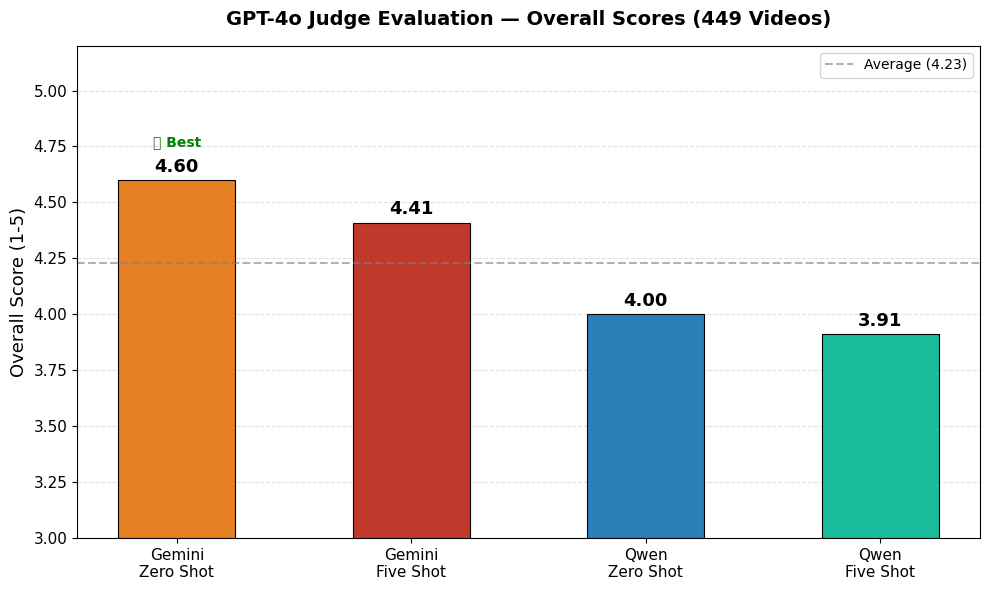

✅ Graph 1 saved!


/tmp/ipykernel_594/3385750127.py:129: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_594/3385750127.py:129: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_594/3385750127.py:130: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_594/3385750127.py:130: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


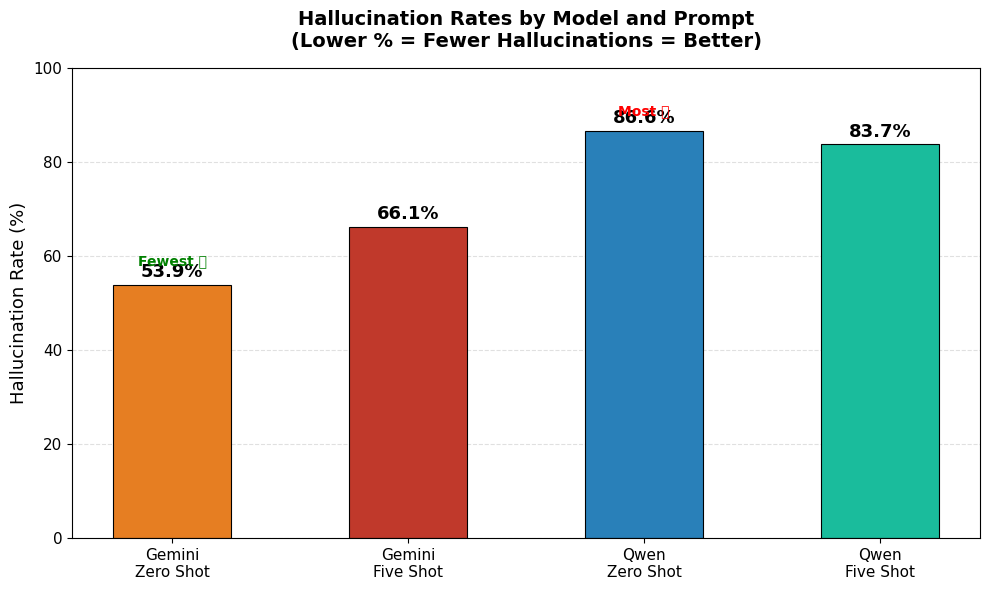

✅ Graph 2 saved!


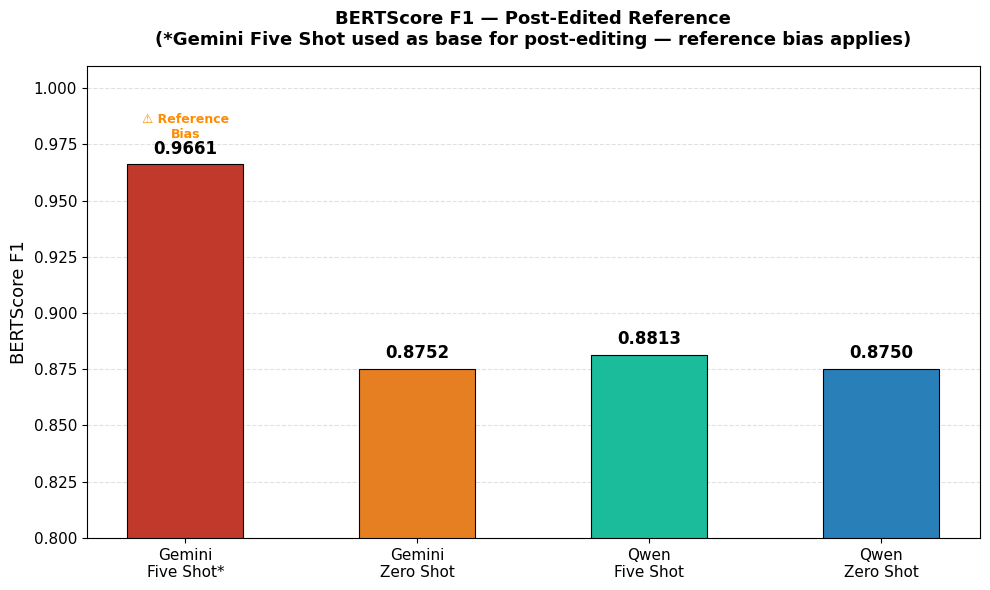

✅ Graph 3 saved!


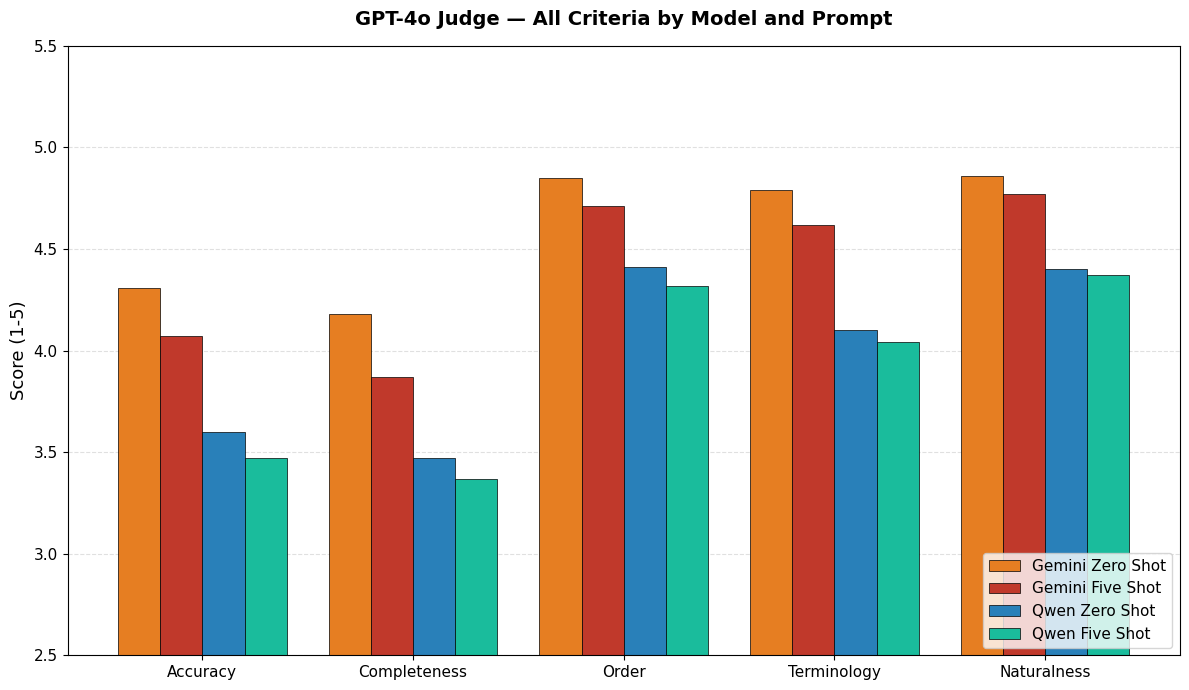

✅ Graph 4 saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All 4 graphs downloaded!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("/content/graphs", exist_ok=True)

GEMINI_ZERO = "#E67E22"
GEMINI_FIVE = "#C0392B"
QWEN_ZERO   = "#2980B9"
QWEN_FIVE   = "#1ABC9C"

models = [
    "Gemini\nZero Shot",
    "Gemini\nFive Shot",
    "Qwen\nZero Shot",
    "Qwen\nFive Shot"
]
colors = [GEMINI_ZERO, GEMINI_FIVE,
          QWEN_ZERO, QWEN_FIVE]

#  GRAPH 1: Overall Scores
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

overall = [4.60, 4.41, 4.00, 3.91]
bars = ax.bar(models, overall,
              color=colors, width=0.5,
              edgecolor="black",
              linewidth=0.8)

for bar, val in zip(bars, overall):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold",
        color="black"
    )

ax.text(
    bars[0].get_x() + bars[0].get_width()/2,
    4.75, " Best",
    ha="center", fontsize=10,
    color="green", fontweight="bold"
)

ax.set_ylim(3.0, 5.2)
ax.set_ylabel("Overall Score (1-5)",
              fontsize=13, color="black")
ax.set_title(
    "GPT-4o Judge Evaluation — Overall Scores (449 Videos)",
    fontsize=14, fontweight="bold",
    color="black", pad=15
)
ax.tick_params(colors="black", labelsize=11)
ax.spines[:].set_color("black")
ax.yaxis.grid(True, color="lightgray",
              linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

avg = sum(overall)/len(overall)
ax.axhline(y=avg, color="gray",
           linestyle="--", alpha=0.6,
           label=f"Average ({avg:.2f})")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    "/content/graphs/graph1_overall.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("✅ Graph 1 saved!")

#  GRAPH 2: Hallucination Rates
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

hall_rates = [53.9, 66.1, 86.6, 83.7]
bars = ax.bar(models, hall_rates,
              color=colors, width=0.5,
              edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, hall_rates):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{val}%",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold",
        color="black"
    )

ax.text(
    bars[0].get_x() + bars[0].get_width()/2,
    58, "Fewest ",
    ha="center", fontsize=10,
    color="green", fontweight="bold"
)
ax.text(
    bars[2].get_x() + bars[2].get_width()/2,
    90, "Most ",
    ha="center", fontsize=10,
    color="red", fontweight="bold"
)

ax.set_ylim(0, 100)
ax.set_ylabel("Hallucination Rate (%)",
              fontsize=13, color="black")
ax.set_title(
    "Hallucination Rates by Model and Prompt\n(Lower % = Fewer Hallucinations = Better)",
    fontsize=14, fontweight="bold",
    color="black", pad=15
)
ax.tick_params(colors="black", labelsize=11)
ax.spines[:].set_color("black")
ax.yaxis.grid(True, color="lightgray",
              linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "/content/graphs/graph2_hallucination.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print(" Graph 2 saved!")

#  GRAPH 3: BERTScore
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bert_models = [
    "Gemini\nFive Shot*",
    "Gemini\nZero Shot",
    "Qwen\nFive Shot",
    "Qwen\nZero Shot"
]
bert_colors = [GEMINI_FIVE, GEMINI_ZERO,
               QWEN_FIVE, QWEN_ZERO]
bert_scores = [0.9661, 0.8752, 0.8813, 0.8750]

bars = ax.bar(bert_models, bert_scores,
              color=bert_colors, width=0.5,
              edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, bert_scores):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold",
        color="black"
    )

ax.text(
    bars[0].get_x() + bars[0].get_width()/2,
    0.978, " Reference\nBias",
    ha="center", fontsize=9,
    color="darkorange", fontweight="bold"
)

ax.set_ylim(0.80, 1.01)
ax.set_ylabel("BERTScore F1",
              fontsize=13, color="black")
ax.set_title(
    "BERTScore F1 — Post-Edited Reference\n(*Gemini Five Shot used as base for post-editing — reference bias applies)",
    fontsize=13, fontweight="bold",
    color="black", pad=15
)
ax.tick_params(colors="black", labelsize=11)
ax.spines[:].set_color("black")
ax.yaxis.grid(True, color="lightgray",
              linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "/content/graphs/graph3_bertscore.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print(" Graph 3 saved!")

#  GRAPH 4: Grouped Bar Chart

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

criteria = [
    "Accuracy", "Completeness",
    "Order", "Terminology", "Naturalness"
]

gemini_zero = [4.31, 4.18, 4.85, 4.79, 4.86]
gemini_five = [4.07, 3.87, 4.71, 4.62, 4.77]
qwen_zero   = [3.60, 3.47, 4.41, 4.10, 4.40]
qwen_five   = [3.47, 3.37, 4.32, 4.04, 4.37]

x = np.arange(len(criteria))
width = 0.2

b1 = ax.bar(x - 1.5*width, gemini_zero,
            width, label="Gemini Zero Shot",
            color=GEMINI_ZERO,
            edgecolor="black", linewidth=0.5)
b2 = ax.bar(x - 0.5*width, gemini_five,
            width, label="Gemini Five Shot",
            color=GEMINI_FIVE,
            edgecolor="black", linewidth=0.5)
b3 = ax.bar(x + 0.5*width, qwen_zero,
            width, label="Qwen Zero Shot",
            color=QWEN_ZERO,
            edgecolor="black", linewidth=0.5)
b4 = ax.bar(x + 1.5*width, qwen_five,
            width, label="Qwen Five Shot",
            color=QWEN_FIVE,
            edgecolor="black", linewidth=0.5)

ax.set_ylim(2.5, 5.5)
ax.set_ylabel("Score (1-5)",
              fontsize=13, color="black")
ax.set_title(
    "GPT-4o Judge — All Criteria by Model and Prompt",
    fontsize=14, fontweight="bold",
    color="black", pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(criteria,
                   fontsize=12, color="black")
ax.tick_params(colors="black", labelsize=11)
ax.spines[:].set_color("black")
ax.yaxis.grid(True, color="lightgray",
              linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=11,
          loc="lower right")

plt.tight_layout()
plt.savefig(
    "/content/graphs/graph4_grouped.png",
    dpi=300, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print(" Graph 4 saved!")


import shutil
from google.colab import files

shutil.make_archive(
    "/content/dissertation_graphs",
    "zip",
    "/content/graphs"
)
files.download(
    "/content/dissertation_graphs.zip"
)
print("\n All 4 graphs downloaded!")